# Logistic Regression Model on Personal Transactions Data

Alisa Crowe

CS 549, Spring 2026

## Imports & Data Loading

In [1]:
import sys

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, make_scorer
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split

In [3]:
sys.path.insert(0, "../data")
from data_loading import load_train_test_split

X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

print("train:", X_train.shape, y_train.shape)
print("test: ", X_test.shape, y_test.shape)


train: (8644, 60) (8644,)
test:  (2162, 60) (2162,)


In [27]:
X_train

,Transaction Type,Day of Week,Month,Amount_scaled,Desc_Amazon,Desc_Amazon Video,Desc_American Tavern,Desc_BBQ Restaurant,Desc_BP,Desc_Bakery Place,...,Desc_State Farm,Desc_Sushi Restaurant,Desc_Target,Desc_Thai Restaurant,Desc_Valero,Desc_Vietnamese Restaurant,Desc_Wendy's,Acct_Checking,Acct_Platinum Card,Acct_Silver Card
6983,1,1,5,0.366366,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
10759,0,5,11,-0.293635,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
6149,0,6,6,0.209318,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
5548,0,4,9,0.095156,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
5127,1,3,7,-0.293380,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2594,1,0,4,0.061919,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3800,0,5,12,-0.497144,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
7085,0,5,12,-0.175440,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
6761,1,5,10,-0.126069,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


## Model Training & Evaluation
### Baseline Model

In [30]:
# define logistic regression model
clf1 = LogisticRegression(max_iter=2000)


In [32]:
# fit on training data
clf1.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [34]:
# evaluate on test data
y_pred = clf1.predict(X_test)

# print results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.18917668825161887
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        55
           1       0.00      0.00      0.00        77
           2       0.00      0.00      0.00        86
           3       0.19      0.62      0.29       356
           4       0.00      0.00      0.00        21
           5       0.00      0.00      0.00         4
           6       0.00      0.00      0.00        35
           7       0.00      0.00      0.00         5
           8       0.18      0.03      0.05       130
           9       0.16      0.34      0.22       289
          10       0.00      0.00      0.00        44
          11       0.00      0.00      0.00        88
          12       0.00      0.00      0.00        66
          13       0.40      0.08      0.14        49
          14       0.75      0.06      0.11        49
          15       0.00      0.00      0.00        46
          16       0.10     

/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

## Hyperparamter Tuning

### Regularization Selection with No Class Weighting

In [ ]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

cv_acc_scores = []
cv_f1_scores = []

test_acc_scores = []
test_f1_scores = []

for C in C_values:
    print(f"Training with C = {C}")

    clf = LogisticRegression(max_iter=2000, C=C)
    clf.fit(X_train, y_train)

    # cross-validation scores
    acc_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')

    cv_acc_scores.append(acc_scores.mean())
    cv_f1_scores.append(f1_scores.mean())

    # test set evaluation
    y_pred = clf.predict(X_test)

    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average='macro')

    test_acc_scores.append(test_acc)
    test_f1_scores.append(test_f1)

    print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
    print(f"Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}")
    print("-" * 50)

# plotting
plt.figure()

# cross-validation curves
plt.plot(C_values, cv_acc_scores, marker='o', label='CV Accuracy')
plt.plot(C_values, cv_f1_scores, marker='o', linestyle='--', label='CV F1 (macro)')

# test curves
plt.plot(C_values, test_acc_scores, marker='s', label='Test Accuracy')
plt.plot(C_values, test_f1_scores, marker='s', linestyle='--', label='Test F1 (macro)')

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Score')
plt.title('Effect of C on Logistic Regression (Accuracy & F1)')
plt.legend()

plt.savefig("logistic_regression_C_tuning_acc_f1.png")
plt.show()

### Analysis of Regularization

Because of the large class imbalance in our dataset, we will prioritize improvement of the macro F1 score over the accuracy. From the figure above, we can see that a regularization term of C=10 maximizes the F1 score for the test set. The value C=100 exhibits a decreased F1 score with only a slight increase in accuracy, so a value of C=10 will be selected for the model.

### Hyperparameter Tuning: Class Imbalance

In [ ]:
# parameters to test
C_values = [0.1, 1, 10, 100]
class_weights = ['balanced']

# store results
results = {}

for cw in class_weights:
    label = 'balanced' if cw == 'balanced' else 'none'
    
    cv_acc_scores = []
    cv_f1_scores = []
    test_acc_scores = []
    test_f1_scores = []
    
    print(f"\n=== Testing class_weight = {cw} ===")
    
    for C in C_values:
        print(f"Training with C = {C}")
        
        clf = LogisticRegression(
            max_iter=2000,
            C=C,
            class_weight=cw
        )
        
        clf.fit(X_train, y_train)
        
        # cross-validation
        acc_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
        f1_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')
        
        cv_acc_scores.append(acc_scores.mean())
        cv_f1_scores.append(f1_scores.mean())
        
        # test set
        y_pred = clf.predict(X_test)
        
        test_acc = accuracy_score(y_test, y_pred)
        test_f1 = f1_score(y_test, y_pred, average='macro')
        
        test_acc_scores.append(test_acc)
        test_f1_scores.append(test_f1)
        
        print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
        print(f"Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}")
        print("-" * 50)
    
    results[label] = {
        'cv_acc': cv_acc_scores,
        'cv_f1': cv_f1_scores,
        'test_acc': test_acc_scores,
        'test_f1': test_f1_scores
    }

# plot
plt.figure()

for label in results:
    plt.plot(
        C_values,
        results[label]['cv_f1'],
        marker='o',
        label=f'CV F1 ({label})'
    )
    
    plt.plot(
        C_values,
        results[label]['test_f1'],
        marker='s',
        linestyle='--',
        label=f'Test F1 ({label})'
    )

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('F1 Macro Score')
plt.title('Effect of Class Weight on Logistic Regression')
plt.legend()

plt.savefig("logreg_class_weight_comparison.png")
plt.show()

### Analysis of Balanced Classes

Because class weighting reduces bias toward majority classes, these are predicted less often, thus the model's overall accuracy decreases. However, we would expect to see a rise in F1-score after balancing classes. Since we see minimal change in F1-score at C=10, this indicates that the model is struggling with linearly separating classes.

### Hyperparameter Tuning: Penalty Types


=== Testing penalty = L2 ===
Training with C = 0.1
CV Acc: 0.1807, CV F1: 0.0477
Test Acc: 0.1901, Test F1: 0.0531
--------------------------------------------------
Training with C = 1
CV Acc: 0.1838, CV F1: 0.0640
Test Acc: 0.1892, Test F1: 0.0660
--------------------------------------------------
Training with C = 10


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


CV Acc: 0.1824, CV F1: 0.0679
Test Acc: 0.1915, Test F1: 0.0717
--------------------------------------------------
Training with C = 100


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did 

CV Acc: 0.1824, CV F1: 0.0683
Test Acc: 0.1906, Test F1: 0.0716
--------------------------------------------------

=== Testing penalty = L1 ===
Training with C = 0.1
CV Acc: 0.1752, CV F1: 0.0340
Test Acc: 0.1799, Test F1: 0.0362
--------------------------------------------------
Training with C = 1
CV Acc: 0.1824, CV F1: 0.0638
Test Acc: 0.1901, Test F1: 0.0655
--------------------------------------------------
Training with C = 10


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did 

CV Acc: 0.1824, CV F1: 0.0679
Test Acc: 0.1892, Test F1: 0.0712
--------------------------------------------------
Training with C = 100


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did 

CV Acc: 0.1824, CV F1: 0.0683
Test Acc: 0.1901, Test F1: 0.0713
--------------------------------------------------


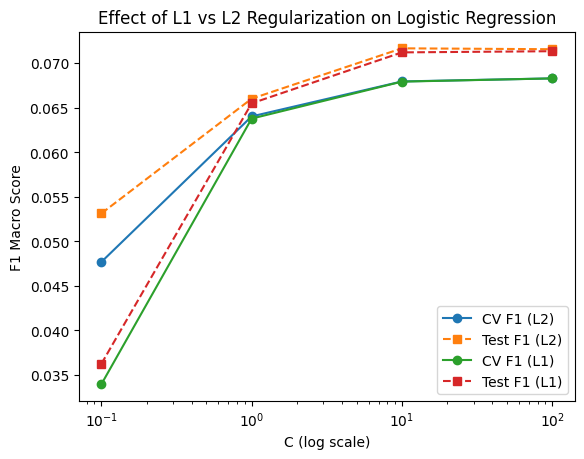

In [18]:
# parameters to test
C_values = [0.1, 1, 10, 100]

# l1_ratio=0 means L2 penalty
# l1_ratio=1 means L1 penalty
l1_ratios = [0, 1]

# store results
results = {}

for l1_ratio in l1_ratios:
    label = 'L2' if l1_ratio == 0 else 'L1'
    
    cv_acc_scores = []
    cv_f1_scores = []
    test_acc_scores = []
    test_f1_scores = []
    
    print(f"\n=== Testing penalty = {label} ===")
    
    for C in C_values:
        print(f"Training with C = {C}")
        
        clf = LogisticRegression(
            max_iter=5000,
            C=C,
            solver='saga',
            l1_ratio=l1_ratio
        )
        
        clf.fit(X_train, y_train)
        
        # cross-validation
        acc_scores = cross_val_score(
            clf, X_train, y_train, cv=5, scoring='accuracy'
        )
        
        f1_scores = cross_val_score(
            clf, X_train, y_train, cv=5, scoring='f1_macro'
        )
        
        cv_acc_scores.append(acc_scores.mean())
        cv_f1_scores.append(f1_scores.mean())
        
        # test set
        y_pred = clf.predict(X_test)
        
        test_acc = accuracy_score(y_test, y_pred)
        test_f1 = f1_score(y_test, y_pred, average='macro')
        
        test_acc_scores.append(test_acc)
        test_f1_scores.append(test_f1)
        
        print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
        print(f"Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}")
        print("-" * 50)
    
    results[label] = {
        'cv_acc': cv_acc_scores,
        'cv_f1': cv_f1_scores,
        'test_acc': test_acc_scores,
        'test_f1': test_f1_scores
    }

# plot
plt.figure()

for label in results:
    plt.plot(
        C_values,
        results[label]['cv_f1'],
        marker='o',
        label=f'CV F1 ({label})'
    )
    
    plt.plot(
        C_values,
        results[label]['test_f1'],
        marker='s',
        linestyle='--',
        label=f'Test F1 ({label})'
    )

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('F1 Macro Score')
plt.title('Effect of L1 vs L2 Regularization on Logistic Regression')
plt.legend()

plt.savefig("logreg_l1_l2_comparison.png")
plt.show()

### Hyperparameter Tuning: L1 vs L2 Regularization


=== Penalty = L2, Class Weight = None ===
Training with C = 0.1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' in

CV Acc: 0.1807, CV F1: 0.0477
Test Acc: 0.1901, Test F1: 0.0531
--------------------------------------------------
Training with C = 1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' in

CV Acc: 0.1838, CV F1: 0.0640
Test Acc: 0.1892, Test F1: 0.0660
--------------------------------------------------
Training with C = 10


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/li

CV Acc: 0.1824, CV F1: 0.0679
Test Acc: 0.1915, Test F1: 0.0717
--------------------------------------------------
Training with C = 100


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/li

CV Acc: 0.1824, CV F1: 0.0683
Test Acc: 0.1906, Test F1: 0.0716
--------------------------------------------------

=== Penalty = L1, Class Weight = None ===
Training with C = 0.1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/

CV Acc: 0.1752, CV F1: 0.0340
Test Acc: 0.1799, Test F1: 0.0362
--------------------------------------------------
Training with C = 1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/

CV Acc: 0.1824, CV F1: 0.0638
Test Acc: 0.1901, Test F1: 0.0655
--------------------------------------------------
Training with C = 10


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/

CV Acc: 0.1824, CV F1: 0.0679
Test Acc: 0.1892, Test F1: 0.0712
--------------------------------------------------
Training with C = 100


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n

CV Acc: 0.1824, CV F1: 0.0683
Test Acc: 0.1901, Test F1: 0.0713
--------------------------------------------------

=== Penalty = L2, Class Weight = Balanced ===
Training with C = 0.1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' in

CV Acc: 0.0758, CV F1: 0.0675
Test Acc: 0.0814, Test F1: 0.0692
--------------------------------------------------
Training with C = 1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' in

CV Acc: 0.0798, CV F1: 0.0701
Test Acc: 0.0842, Test F1: 0.0704
--------------------------------------------------
Training with C = 10


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' in

CV Acc: 0.0795, CV F1: 0.0701
Test Acc: 0.0856, Test F1: 0.0713
--------------------------------------------------
Training with C = 100


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' in

CV Acc: 0.0795, CV F1: 0.0699
Test Acc: 0.0856, Test F1: 0.0714
--------------------------------------------------

=== Penalty = L1, Class Weight = Balanced ===
Training with C = 0.1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/

CV Acc: 0.0681, CV F1: 0.0623
Test Acc: 0.0791, Test F1: 0.0676
--------------------------------------------------
Training with C = 1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/

CV Acc: 0.0796, CV F1: 0.0695
Test Acc: 0.0833, Test F1: 0.0706
--------------------------------------------------
Training with C = 10


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/

CV Acc: 0.0799, CV F1: 0.0702
Test Acc: 0.0846, Test F1: 0.0708
--------------------------------------------------
Training with C = 100


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/

CV Acc: 0.0794, CV F1: 0.0696
Test Acc: 0.0856, Test F1: 0.0714
--------------------------------------------------


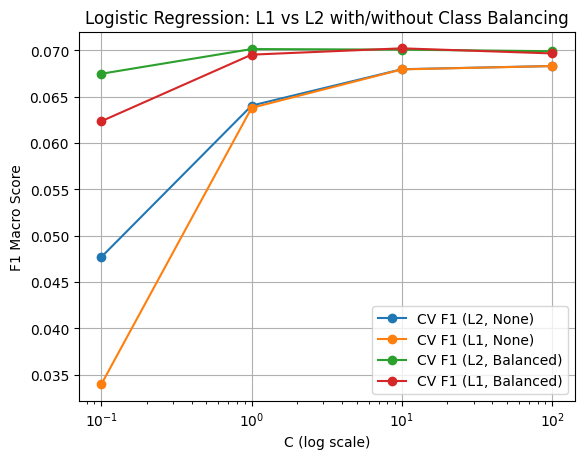


===== Class balance = None =====

L2
CV Acc: [np.float64(0.1807), np.float64(0.1838), np.float64(0.1824), np.float64(0.1824)]
CV F1 : [np.float64(0.0477), np.float64(0.064), np.float64(0.0679), np.float64(0.0683)]
Test Acc: [0.1901, 0.1892, 0.1915, 0.1906]
Test F1 : [0.0531, 0.066, 0.0717, 0.0716]

L1
CV Acc: [np.float64(0.1752), np.float64(0.1824), np.float64(0.1824), np.float64(0.1824)]
CV F1 : [np.float64(0.034), np.float64(0.0638), np.float64(0.0679), np.float64(0.0683)]
Test Acc: [0.1799, 0.1901, 0.1892, 0.1901]
Test F1 : [0.0362, 0.0655, 0.0712, 0.0713]

===== Class balance = Balanced =====

L2
CV Acc: [np.float64(0.0758), np.float64(0.0798), np.float64(0.0795), np.float64(0.0795)]
CV F1 : [np.float64(0.0675), np.float64(0.0701), np.float64(0.0701), np.float64(0.0699)]
Test Acc: [0.0814, 0.0842, 0.0856, 0.0856]
Test F1 : [0.0692, 0.0704, 0.0713, 0.0714]

L1
CV Acc: [np.float64(0.0681), np.float64(0.0796), np.float64(0.0799), np.float64(0.0794)]
CV F1 : [np.float64(0.0623), np.fl

In [21]:
# parameters to test
C_values = [0.1, 1, 10, 100]
penalties = ['l2', 'l1']
class_weights = [None, 'balanced']

# store results
results = {}

for cw in class_weights:
    cw_label = 'None' if cw is None else 'Balanced'
    results[cw_label] = {}

    for penalty in penalties:
        label = penalty.upper()

        cv_acc_scores = []
        cv_f1_scores = []
        test_acc_scores = []
        test_f1_scores = []

        print(f"\n=== Penalty = {label}, Class Weight = {cw_label} ===")

        for C in C_values:
            print(f"Training with C = {C}")

            clf = LogisticRegression(
                max_iter=5000,
                C=C,
                solver='saga',
                penalty=penalty,
                class_weight=cw,
                random_state=42,
                n_jobs=-1
            )

            # Cross-validation
            acc_scores = cross_val_score(
                clf, X_train, y_train, cv=5, scoring='accuracy'
            )

            f1_scores = cross_val_score(
                clf, X_train, y_train, cv=5, scoring='f1_macro'
            )

            cv_acc_scores.append(acc_scores.mean())
            cv_f1_scores.append(f1_scores.mean())

            # Train on full training set
            clf.fit(X_train, y_train)

            # Test evaluation
            y_pred = clf.predict(X_test)

            test_acc = accuracy_score(y_test, y_pred)
            test_f1 = f1_score(y_test, y_pred, average='macro')

            test_acc_scores.append(test_acc)
            test_f1_scores.append(test_f1)

            print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
            print(f"Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}")
            print("-" * 50)

        results[cw_label][label] = {
            'cv_acc': cv_acc_scores,
            'cv_f1': cv_f1_scores,
            'test_acc': test_acc_scores,
            'test_f1': test_f1_scores
        }

# -------- Plot --------
plt.figure()

for cw_label in results:
    for label in results[cw_label]:
        plt.plot(
            C_values,
            results[cw_label][label]['cv_f1'],
            marker='o',
            label=f'CV F1 ({label}, {cw_label})'
        )

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('F1 Macro Score')
plt.title('Logistic Regression: L1 vs L2 with/without Class Balancing')
plt.legend()
plt.grid(True)

plt.savefig("logreg_full_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# -------- Print Results --------
for cw_label in results:
    print(f"\n===== Class balance = {cw_label} =====")
    for label in results[cw_label]:
        print(f"\n{label}")
        print("CV Acc:", [round(x, 4) for x in results[cw_label][label]['cv_acc']])
        print("CV F1 :", [round(x, 4) for x in results[cw_label][label]['cv_f1']])
        print("Test Acc:", [round(x, 4) for x in results[cw_label][label]['test_acc']])
        print("Test F1 :", [round(x, 4) for x in results[cw_label][label]['test_f1']])

### Experiment with Data Removal: Description Columns

In [57]:
X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

print("train:", X_train.shape, y_train.shape)
print("test: ", X_test.shape, y_test.shape)

train: (8644, 60) (8644,)
test:  (2162, 60) (2162,)


In [59]:
X_train = X_train.loc[:, ~X_train.columns.str.startswith("Desc_")]
X_test  = X_test.loc[:, ~X_test.columns.str.startswith("Desc_")]

In [61]:
X_train

,Transaction Type,Day of Week,Month,Amount_scaled,Acct_Checking,Acct_Platinum Card,Acct_Silver Card
6983,1,1,5,0.366366,1,0,0
10759,0,5,11,-0.293635,1,0,0
6149,0,6,6,0.209318,0,1,0
5548,0,4,9,0.095156,0,1,0
5127,1,3,7,-0.293380,0,0,1
...,...,...,...,...,...,...,...
2594,1,0,4,0.061919,0,0,1
3800,0,5,12,-0.497144,0,1,0
7085,0,5,12,-0.175440,1,0,0
6761,1,5,10,-0.126069,1,0,0



=== No Desc Columns: Penalty = L2, Class Weight = Balanced ===
Training with C = 1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated

CV Acc: 0.0281, CV F1: 0.0261
Test Acc: 0.0291, Test F1: 0.0266
--------------------------------------------------
Training with C = 10


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated

CV Acc: 0.0279, CV F1: 0.0258
Test Acc: 0.0291, Test F1: 0.0266
--------------------------------------------------


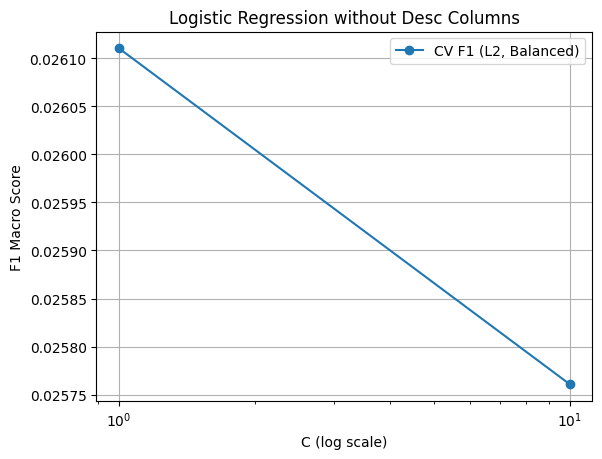


===== No Desc Columns: Class balance = Balanced =====

L2
CV Acc: [0.0281, 0.0279]
CV F1 : [0.0261, 0.0258]
Test Acc: [0.0291, 0.0291]
Test F1 : [0.0266, 0.0266]


In [91]:
# parameters to test
C_values = [1, 10]
penalties = ['l2']
class_weights = ['balanced']

# store results
results_no_desc = {}

for cw in class_weights:
    cw_label = 'None' if cw is None else 'Balanced'
    results_no_desc[cw_label] = {}

    for penalty in penalties:
        label = penalty.upper()

        cv_acc_scores = []
        cv_f1_scores = []
        test_acc_scores = []
        test_f1_scores = []

        print(f"\n=== No Desc Columns: Penalty = {label}, Class Weight = {cw_label} ===")

        for C in C_values:
            print(f"Training with C = {C}")

            clf = LogisticRegression(
                max_iter=5000,
                C=C,
                solver='saga',
                penalty=penalty,
                class_weight=cw,
                random_state=42
            )

            # cross-validation
            acc_scores = cross_val_score(
                clf, X_train, y_train, cv=5, scoring='accuracy'
            )

            f1_scores = cross_val_score(
                clf, X_train, y_train, cv=5, scoring='f1_macro'
            )

            cv_acc_scores.append(acc_scores.mean())
            cv_f1_scores.append(f1_scores.mean())

            # train on full training set
            clf.fit(X_train, y_train)

            # test evaluation
            y_pred = clf.predict(X_test)

            test_acc = accuracy_score(y_test, y_pred)
            test_f1 = f1_score(y_test, y_pred, average='macro')

            test_acc_scores.append(test_acc)
            test_f1_scores.append(test_f1)

            print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
            print(f"Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}")
            print("-" * 50)

        results_no_desc[cw_label][label] = {
            'cv_acc': cv_acc_scores,
            'cv_f1': cv_f1_scores,
            'test_acc': test_acc_scores,
            'test_f1': test_f1_scores
        }

# -------- Plot --------
plt.figure()

for cw_label in results_no_desc:
    for label in results_no_desc[cw_label]:
        plt.plot(
            C_values,
            results_no_desc[cw_label][label]['cv_f1'],
            marker='o',
            label=f'CV F1 ({label}, {cw_label})'
        )

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('F1 Macro Score')
plt.title('Logistic Regression without Desc Columns')
plt.legend()
plt.grid(True)

plt.savefig("logreg_no_desc_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# -------- Print Results --------
for cw_label in results_no_desc:
    print(f"\n===== No Desc Columns: Class balance = {cw_label} =====")
    for label in results_no_desc[cw_label]:
        print(f"\n{label}")
        print("CV Acc:", [round(float(x), 4) for x in results_no_desc[cw_label][label]['cv_acc']])
        print("CV F1 :", [round(float(x), 4) for x in results_no_desc[cw_label][label]['cv_f1']])
        print("Test Acc:", [round(float(x), 4) for x in results_no_desc[cw_label][label]['test_acc']])
        print("Test F1 :", [round(float(x), 4) for x in results_no_desc[cw_label][label]['test_f1']])

Conclusion: Keep Description Columns (Improved F-1 Score)

### Experiment with Amount Field Log Transformed

In [97]:
df = pd.read_csv("../data/cleaned/transactions_cleaned_amount.csv")

In [101]:
df.head()

,Date,Amount,Transaction Type,Category,Day of Week,Month,Description_grouped,Desc_Amazon,Desc_Amazon Video,Desc_American Tavern,...,Desc_Thai Restaurant,Desc_Valero,Desc_Vietnamese Restaurant,Desc_Wendy's,Acct_Checking,Acct_Platinum Card,Acct_Silver Card,Category_label,Amount_log,Amount_log_scaled
0,2018-01-01,11.11,1,Shopping,0,1,Amazon,1,0,0,...,0,0,0,0,0,1,0,19,2.494032,-1.868738
1,2018-01-02,1247.44,1,Mortgage & Rent,1,1,Mortgage Payment,0,0,0,...,0,0,0,0,1,0,0,14,7.129650,2.878211
2,2018-01-02,24.22,1,Restaurants,1,1,Thai Restaurant,0,0,0,...,1,0,0,0,0,0,1,18,3.227637,-1.117514
3,2018-01-03,2298.09,0,Credit Card Payment,2,1,Credit Card Payment,0,0,0,...,0,0,0,0,0,1,0,3,7.740269,3.503495
4,2018-01-04,11.76,1,Movies & DVDs,3,1,Netflix,0,0,0,...,0,0,0,0,0,1,0,15,2.546315,-1.815199


In [103]:
feature_cols = (
    ["Transaction Type", "Day of Week", "Month", "Amount_log_scaled"]
    + [c for c in df.columns if c.startswith("Desc_")]
    + [c for c in df.columns if c.startswith("Acct_")]
)

In [105]:
feature_cols = (
    ["Transaction Type", "Day of Week", "Month", "Amount_log_scaled"]
    + [c for c in df.columns if c.startswith("Desc_")]
    + [c for c in df.columns if c.startswith("Acct_")]
)
X = df[feature_cols]
y = df["Category_label"]

In [111]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Number of features:", len(feature_cols))

X_train shape: (8644, 60)
X_test shape: (2162, 60)
Number of features: 60



=== No Desc Columns: Penalty = L2, Class Weight = Balanced ===
Training with C = 1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated

CV Acc: 0.0795, CV F1: 0.0700
Test Acc: 0.0819, Test F1: 0.0705
--------------------------------------------------
Training with C = 10


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated

CV Acc: 0.0791, CV F1: 0.0700
Test Acc: 0.0796, Test F1: 0.0686
--------------------------------------------------


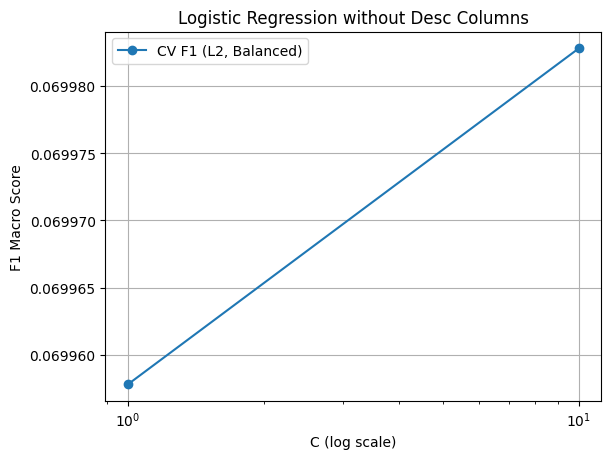


===== No Desc Columns: Class balance = Balanced =====

L2
CV Acc: [0.0795, 0.0791]
CV F1 : [0.07, 0.07]
Test Acc: [0.0819, 0.0796]
Test F1 : [0.0705, 0.0686]


In [113]:
# parameters to test
C_values = [1, 10]
penalties = ['l2']
class_weights = ['balanced']

# store results
results_no_desc = {}

for cw in class_weights:
    cw_label = 'None' if cw is None else 'Balanced'
    results_no_desc[cw_label] = {}

    for penalty in penalties:
        label = penalty.upper()

        cv_acc_scores = []
        cv_f1_scores = []
        test_acc_scores = []
        test_f1_scores = []

        print(f"\n=== No Desc Columns: Penalty = {label}, Class Weight = {cw_label} ===")

        for C in C_values:
            print(f"Training with C = {C}")

            clf = LogisticRegression(
                max_iter=5000,
                C=C,
                solver='saga',
                penalty=penalty,
                class_weight=cw,
                random_state=42
            )

            # cross-validation
            acc_scores = cross_val_score(
                clf, X_train, y_train, cv=5, scoring='accuracy'
            )

            f1_scores = cross_val_score(
                clf, X_train, y_train, cv=5, scoring='f1_macro'
            )

            cv_acc_scores.append(acc_scores.mean())
            cv_f1_scores.append(f1_scores.mean())

            # train on full training set
            clf.fit(X_train, y_train)

            # test evaluation
            y_pred = clf.predict(X_test)

            test_acc = accuracy_score(y_test, y_pred)
            test_f1 = f1_score(y_test, y_pred, average='macro')

            test_acc_scores.append(test_acc)
            test_f1_scores.append(test_f1)

            print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
            print(f"Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}")
            print("-" * 50)

        results_no_desc[cw_label][label] = {
            'cv_acc': cv_acc_scores,
            'cv_f1': cv_f1_scores,
            'test_acc': test_acc_scores,
            'test_f1': test_f1_scores
        }

# -------- Plot --------
plt.figure()

for cw_label in results_no_desc:
    for label in results_no_desc[cw_label]:
        plt.plot(
            C_values,
            results_no_desc[cw_label][label]['cv_f1'],
            marker='o',
            label=f'CV F1 ({label}, {cw_label})'
        )

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('F1 Macro Score')
plt.title('Logistic Regression without Desc Columns')
plt.legend()
plt.grid(True)

plt.savefig("logreg_no_desc_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# -------- Print Results --------
for cw_label in results_no_desc:
    print(f"\n===== No Desc Columns: Class balance = {cw_label} =====")
    for label in results_no_desc[cw_label]:
        print(f"\n{label}")
        print("CV Acc:", [round(float(x), 4) for x in results_no_desc[cw_label][label]['cv_acc']])
        print("CV F1 :", [round(float(x), 4) for x in results_no_desc[cw_label][label]['cv_f1']])
        print("Test Acc:", [round(float(x), 4) for x in results_no_desc[cw_label][label]['test_acc']])
        print("Test F1 :", [round(float(x), 4) for x in results_no_desc[cw_label][label]['test_f1']])

Conclusion: No notable difference - keep original Amount field 

### Experiment with Feature Engineering & Interaction Features

In [121]:
sys.path.insert(0, "../data")

from data_loading import load_train_test_split
X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

print("train:", X_train.shape, y_train.shape)
print("test: ", X_test.shape, y_test.shape)

train: (8644, 60) (8644,)
test:  (2162, 60) (2162,)


#### 1. Add Season Feature from Month

In [158]:
def month_to_season(m):
    if m in [12, 1, 2]:
        return 0  # Winter
    elif m in [3, 4, 5]:
        return 1  # Spring
    elif m in [6, 7, 8]:
        return 2  # Summer
    else:
        return 3  # Fall

X_train["Season"] = X_train["Month"].apply(month_to_season)
X_test["Season"] = X_test["Month"].apply(month_to_season)


=== No Desc Columns: Penalty = L2, Class Weight = Balanced ===
Training with C = 1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated

CV Acc: 0.0789, CV F1: 0.0696
Test Acc: 0.0837, Test F1: 0.0695
--------------------------------------------------
Training with C = 10


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated

CV Acc: 0.0780, CV F1: 0.0688
Test Acc: 0.0837, Test F1: 0.0700
--------------------------------------------------


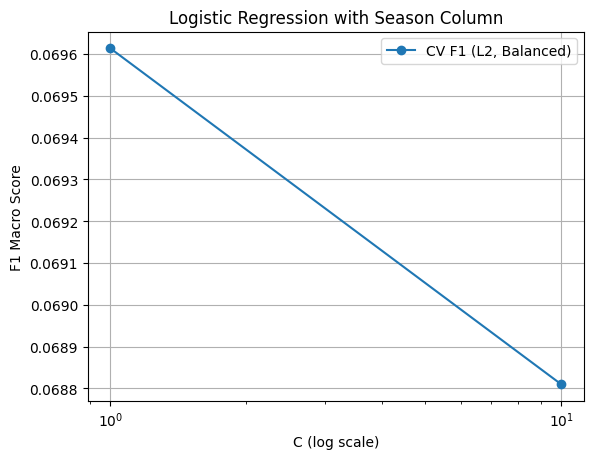


===== Season Column: Class balance = Balanced =====

L2
CV Acc: [0.0789, 0.078]
CV F1 : [0.0696, 0.0688]
Test Acc: [0.0837, 0.0837]
Test F1 : [0.0695, 0.07]


In [160]:
# parameters to test
C_values = [1, 10]
penalties = ['l2']
class_weights = ['balanced']

# store results
results_no_desc = {}

for cw in class_weights:
    cw_label = 'None' if cw is None else 'Balanced'
    results_no_desc[cw_label] = {}

    for penalty in penalties:
        label = penalty.upper()

        cv_acc_scores = []
        cv_f1_scores = []
        test_acc_scores = []
        test_f1_scores = []

        print(f"\n=== No Desc Columns: Penalty = {label}, Class Weight = {cw_label} ===")

        for C in C_values:
            print(f"Training with C = {C}")

            clf = LogisticRegression(
                max_iter=5000,
                C=C,
                solver='saga',
                penalty=penalty,
                class_weight=cw,
                random_state=42
            )

            # cross-validation
            acc_scores = cross_val_score(
                clf, X_train, y_train, cv=5, scoring='accuracy'
            )

            f1_scores = cross_val_score(
                clf, X_train, y_train, cv=5, scoring='f1_macro'
            )

            cv_acc_scores.append(acc_scores.mean())
            cv_f1_scores.append(f1_scores.mean())

            # train on full training set
            clf.fit(X_train, y_train)

            # test evaluation
            y_pred = clf.predict(X_test)

            test_acc = accuracy_score(y_test, y_pred)
            test_f1 = f1_score(y_test, y_pred, average='macro')

            test_acc_scores.append(test_acc)
            test_f1_scores.append(test_f1)

            print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
            print(f"Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}")
            print("-" * 50)

        results_no_desc[cw_label][label] = {
            'cv_acc': cv_acc_scores,
            'cv_f1': cv_f1_scores,
            'test_acc': test_acc_scores,
            'test_f1': test_f1_scores
        }

# -------- Plot --------
plt.figure()

for cw_label in results_no_desc:
    for label in results_no_desc[cw_label]:
        plt.plot(
            C_values,
            results_no_desc[cw_label][label]['cv_f1'],
            marker='o',
            label=f'CV F1 ({label}, {cw_label})'
        )

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('F1 Macro Score')
plt.title('Logistic Regression with Season Column')
plt.legend()
plt.grid(True)

plt.savefig("logreg_season.png", dpi=300, bbox_inches='tight')
plt.show()

# -------- Print Results --------
for cw_label in results_no_desc:
    print(f"\n===== Season Column: Class balance = {cw_label} =====")
    for label in results_no_desc[cw_label]:
        print(f"\n{label}")
        print("CV Acc:", [round(float(x), 4) for x in results_no_desc[cw_label][label]['cv_acc']])
        print("CV F1 :", [round(float(x), 4) for x in results_no_desc[cw_label][label]['cv_f1']])
        print("Test Acc:", [round(float(x), 4) for x in results_no_desc[cw_label][label]['test_acc']])
        print("Test F1 :", [round(float(x), 4) for x in results_no_desc[cw_label][label]['test_f1']])

Conclusion:

#### 2. Add Amount x Transaction Type

In [5]:
X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

X_train["Amount_Transaction_Type"] = X_train["Amount_scaled"]*X_train["Transaction Type"]
X_test["Amount_Transaction_Type"] = X_test["Amount_scaled"]*X_test["Transaction Type"]


=== No Desc Columns: Penalty = L2, Class Weight = Balanced ===
Training with C = 1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated

CV Acc: 0.0795, CV F1: 0.0700
Test Acc: 0.0823, Test F1: 0.0694
--------------------------------------------------
Training with C = 10


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated

CV Acc: 0.0802, CV F1: 0.0708
Test Acc: 0.0833, Test F1: 0.0700
--------------------------------------------------


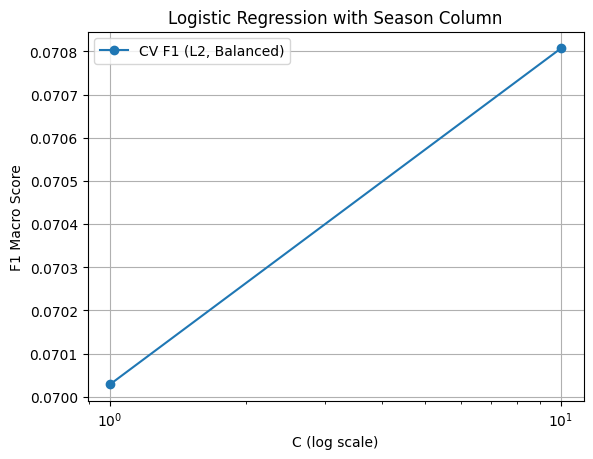


===== Season Column: Class balance = Balanced =====

L2
CV Acc: [0.0795, 0.0802]
CV F1 : [0.07, 0.0708]
Test Acc: [0.0823, 0.0833]
Test F1 : [0.0694, 0.07]


In [7]:
# parameters to test
C_values = [1, 10]
penalties = ['l2']
class_weights = ['balanced']

# store results
results_no_desc = {}

for cw in class_weights:
    cw_label = 'None' if cw is None else 'Balanced'
    results_no_desc[cw_label] = {}

    for penalty in penalties:
        label = penalty.upper()

        cv_acc_scores = []
        cv_f1_scores = []
        test_acc_scores = []
        test_f1_scores = []

        print(f"\n=== No Desc Columns: Penalty = {label}, Class Weight = {cw_label} ===")

        for C in C_values:
            print(f"Training with C = {C}")

            clf = LogisticRegression(
                max_iter=5000,
                C=C,
                solver='saga',
                penalty=penalty,
                class_weight=cw,
                random_state=42
            )

            # cross-validation
            acc_scores = cross_val_score(
                clf, X_train, y_train, cv=5, scoring='accuracy'
            )

            f1_scores = cross_val_score(
                clf, X_train, y_train, cv=5, scoring='f1_macro'
            )

            cv_acc_scores.append(acc_scores.mean())
            cv_f1_scores.append(f1_scores.mean())

            # train on full training set
            clf.fit(X_train, y_train)

            # test evaluation
            y_pred = clf.predict(X_test)

            test_acc = accuracy_score(y_test, y_pred)
            test_f1 = f1_score(y_test, y_pred, average='macro')

            test_acc_scores.append(test_acc)
            test_f1_scores.append(test_f1)

            print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
            print(f"Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}")
            print("-" * 50)

        results_no_desc[cw_label][label] = {
            'cv_acc': cv_acc_scores,
            'cv_f1': cv_f1_scores,
            'test_acc': test_acc_scores,
            'test_f1': test_f1_scores
        }

# -------- Plot --------
plt.figure()

for cw_label in results_no_desc:
    for label in results_no_desc[cw_label]:
        plt.plot(
            C_values,
            results_no_desc[cw_label][label]['cv_f1'],
            marker='o',
            label=f'CV F1 ({label}, {cw_label})'
        )

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('F1 Macro Score')
plt.title('Logistic Regression with Season Column')
plt.legend()
plt.grid(True)

plt.savefig("logreg_season.png", dpi=300, bbox_inches='tight')
plt.show()

# -------- Print Results --------
for cw_label in results_no_desc:
    print(f"\n===== Season Column: Class balance = {cw_label} =====")
    for label in results_no_desc[cw_label]:
        print(f"\n{label}")
        print("CV Acc:", [round(float(x), 4) for x in results_no_desc[cw_label][label]['cv_acc']])
        print("CV F1 :", [round(float(x), 4) for x in results_no_desc[cw_label][label]['cv_f1']])
        print("Test Acc:", [round(float(x), 4) for x in results_no_desc[cw_label][label]['test_acc']])
        print("Test F1 :", [round(float(x), 4) for x in results_no_desc[cw_label][label]['test_f1']])

#### 3. Add Amount x Account Type

In [13]:
X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

account_cols = [
    "Acct_Platinum Card",
    "Acct_Checking",
    "Acct_Silver Card"
]

for col in account_cols:
    X_train[f"Amount_{col}"] = X_train["Amount_scaled"] * X_train[col]
    X_test[f"Amount_{col}"] = X_test["Amount_scaled"] * X_test[col]

X_train.head()

,Transaction Type,Day of Week,Month,Amount_scaled,Desc_Amazon,Desc_Amazon Video,Desc_American Tavern,Desc_BBQ Restaurant,Desc_BP,Desc_Bakery Place,...,Desc_Thai Restaurant,Desc_Valero,Desc_Vietnamese Restaurant,Desc_Wendy's,Acct_Checking,Acct_Platinum Card,Acct_Silver Card,Amount_Acct_Platinum Card,Amount_Acct_Checking,Amount_Acct_Silver Card
6983,1,1,5,0.366366,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0.000000,0.366366,0.00000
10759,0,5,11,-0.293635,0,0,0,0,0,0,...,0,0,0,0,1,0,0,-0.000000,-0.293635,-0.00000
6149,0,6,6,0.209318,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0.209318,0.000000,0.00000
5548,0,4,9,0.095156,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0.095156,0.000000,0.00000
5127,1,3,7,-0.293380,0,0,0,0,0,0,...,0,0,0,0,0,0,1,-0.000000,-0.000000,-0.29338



=== No Desc Columns: Penalty = L2, Class Weight = Balanced ===
Training with C = 1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated

CV Acc: 0.0791, CV F1: 0.0697
Test Acc: 0.0828, Test F1: 0.0698
--------------------------------------------------
Training with C = 10


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated

CV Acc: 0.0782, CV F1: 0.0696
Test Acc: 0.0846, Test F1: 0.0711
--------------------------------------------------


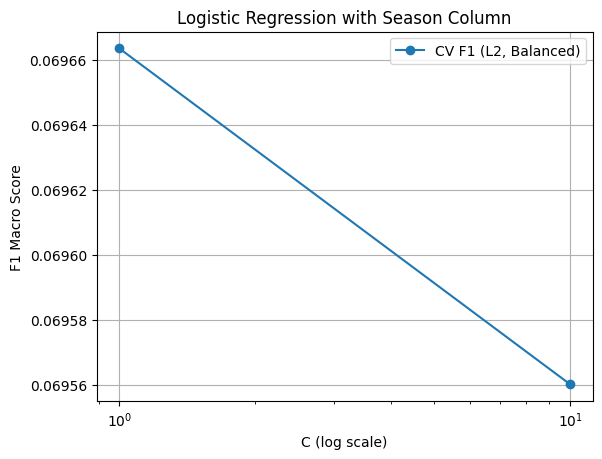


===== Season Column: Class balance = Balanced =====

L2
CV Acc: [0.0791, 0.0782]
CV F1 : [0.0697, 0.0696]
Test Acc: [0.0828, 0.0846]
Test F1 : [0.0698, 0.0711]


In [15]:
# parameters to test
C_values = [1, 10]
penalties = ['l2']
class_weights = ['balanced']

# store results
results_no_desc = {}

for cw in class_weights:
    cw_label = 'None' if cw is None else 'Balanced'
    results_no_desc[cw_label] = {}

    for penalty in penalties:
        label = penalty.upper()

        cv_acc_scores = []
        cv_f1_scores = []
        test_acc_scores = []
        test_f1_scores = []

        print(f"\n=== No Desc Columns: Penalty = {label}, Class Weight = {cw_label} ===")

        for C in C_values:
            print(f"Training with C = {C}")

            clf = LogisticRegression(
                max_iter=5000,
                C=C,
                solver='saga',
                penalty=penalty,
                class_weight=cw,
                random_state=42
            )

            # cross-validation
            acc_scores = cross_val_score(
                clf, X_train, y_train, cv=5, scoring='accuracy'
            )

            f1_scores = cross_val_score(
                clf, X_train, y_train, cv=5, scoring='f1_macro'
            )

            cv_acc_scores.append(acc_scores.mean())
            cv_f1_scores.append(f1_scores.mean())

            # train on full training set
            clf.fit(X_train, y_train)

            # test evaluation
            y_pred = clf.predict(X_test)

            test_acc = accuracy_score(y_test, y_pred)
            test_f1 = f1_score(y_test, y_pred, average='macro')

            test_acc_scores.append(test_acc)
            test_f1_scores.append(test_f1)

            print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
            print(f"Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}")
            print("-" * 50)

        results_no_desc[cw_label][label] = {
            'cv_acc': cv_acc_scores,
            'cv_f1': cv_f1_scores,
            'test_acc': test_acc_scores,
            'test_f1': test_f1_scores
        }

# -------- Plot --------
plt.figure()

for cw_label in results_no_desc:
    for label in results_no_desc[cw_label]:
        plt.plot(
            C_values,
            results_no_desc[cw_label][label]['cv_f1'],
            marker='o',
            label=f'CV F1 ({label}, {cw_label})'
        )

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('F1 Macro Score')
plt.title('Logistic Regression with Season Column')
plt.legend()
plt.grid(True)

plt.savefig("logreg_season.png", dpi=300, bbox_inches='tight')
plt.show()

# -------- Print Results --------
for cw_label in results_no_desc:
    print(f"\n===== Season Column: Class balance = {cw_label} =====")
    for label in results_no_desc[cw_label]:
        print(f"\n{label}")
        print("CV Acc:", [round(float(x), 4) for x in results_no_desc[cw_label][label]['cv_acc']])
        print("CV F1 :", [round(float(x), 4) for x in results_no_desc[cw_label][label]['cv_f1']])
        print("Test Acc:", [round(float(x), 4) for x in results_no_desc[cw_label][label]['test_acc']])
        print("Test F1 :", [round(float(x), 4) for x in results_no_desc[cw_label][label]['test_f1']])

#### 4. Add Day of Week x Transaction Type

In [8]:
X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

X_train["Day_Transaction_Type"] = X_train["Day of Week"]*X_train["Transaction Type"]
X_test["Day_Transaction_Type"] = X_test["Day of Week"]*X_test["Transaction Type"]


=== No Desc Columns: Penalty = L2, Class Weight = Balanced ===
Training with C = 1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated

CV Acc: 0.0797, CV F1: 0.0698
Test Acc: 0.0865, Test F1: 0.0733
--------------------------------------------------
Training with C = 10


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated

CV Acc: 0.0792, CV F1: 0.0694
Test Acc: 0.0860, Test F1: 0.0729
--------------------------------------------------


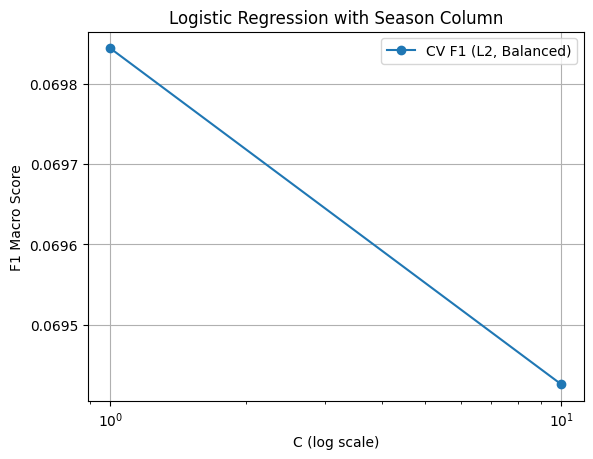


===== Season Column: Class balance = Balanced =====

L2
CV Acc: [0.0797, 0.0792]
CV F1 : [0.0698, 0.0694]
Test Acc: [0.0865, 0.086]
Test F1 : [0.0733, 0.0729]


In [9]:
# parameters to test
C_values = [1, 10]
penalties = ['l2']
class_weights = ['balanced']

# store results
results_no_desc = {}

for cw in class_weights:
    cw_label = 'None' if cw is None else 'Balanced'
    results_no_desc[cw_label] = {}

    for penalty in penalties:
        label = penalty.upper()

        cv_acc_scores = []
        cv_f1_scores = []
        test_acc_scores = []
        test_f1_scores = []

        print(f"\n=== No Desc Columns: Penalty = {label}, Class Weight = {cw_label} ===")

        for C in C_values:
            print(f"Training with C = {C}")

            clf = LogisticRegression(
                max_iter=5000,
                C=C,
                solver='saga',
                penalty=penalty,
                class_weight=cw,
                random_state=42
            )

            # cross-validation
            acc_scores = cross_val_score(
                clf, X_train, y_train, cv=5, scoring='accuracy'
            )

            f1_scores = cross_val_score(
                clf, X_train, y_train, cv=5, scoring='f1_macro'
            )

            cv_acc_scores.append(acc_scores.mean())
            cv_f1_scores.append(f1_scores.mean())

            # train on full training set
            clf.fit(X_train, y_train)

            # test evaluation
            y_pred = clf.predict(X_test)

            test_acc = accuracy_score(y_test, y_pred)
            test_f1 = f1_score(y_test, y_pred, average='macro')

            test_acc_scores.append(test_acc)
            test_f1_scores.append(test_f1)

            print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
            print(f"Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}")
            print("-" * 50)

        results_no_desc[cw_label][label] = {
            'cv_acc': cv_acc_scores,
            'cv_f1': cv_f1_scores,
            'test_acc': test_acc_scores,
            'test_f1': test_f1_scores
        }

# -------- Plot --------
plt.figure()

for cw_label in results_no_desc:
    for label in results_no_desc[cw_label]:
        plt.plot(
            C_values,
            results_no_desc[cw_label][label]['cv_f1'],
            marker='o',
            label=f'CV F1 ({label}, {cw_label})'
        )

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('F1 Macro Score')
plt.title('Logistic Regression with Season Column')
plt.legend()
plt.grid(True)

plt.savefig("logreg_season.png", dpi=300, bbox_inches='tight')
plt.show()

# -------- Print Results --------
for cw_label in results_no_desc:
    print(f"\n===== Season Column: Class balance = {cw_label} =====")
    for label in results_no_desc[cw_label]:
        print(f"\n{label}")
        print("CV Acc:", [round(float(x), 4) for x in results_no_desc[cw_label][label]['cv_acc']])
        print("CV F1 :", [round(float(x), 4) for x in results_no_desc[cw_label][label]['cv_f1']])
        print("Test Acc:", [round(float(x), 4) for x in results_no_desc[cw_label][label]['test_acc']])
        print("Test F1 :", [round(float(x), 4) for x in results_no_desc[cw_label][label]['test_f1']])

#### 5. Add Weekend Indicator

In [15]:
X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

X_train["Is_Weekend"] = X_train["Day of Week"].isin([5, 6]).astype(int)
X_test["Is_Weekend"] = X_test["Day of Week"].isin([5, 6]).astype(int)


=== No Desc Columns: Penalty = L2, Class Weight = Balanced ===
Training with C = 1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated

CV Acc: 0.0799, CV F1: 0.0708
Test Acc: 0.0860, Test F1: 0.0712
--------------------------------------------------
Training with C = 10


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated

CV Acc: 0.0797, CV F1: 0.0708
Test Acc: 0.0860, Test F1: 0.0715
--------------------------------------------------


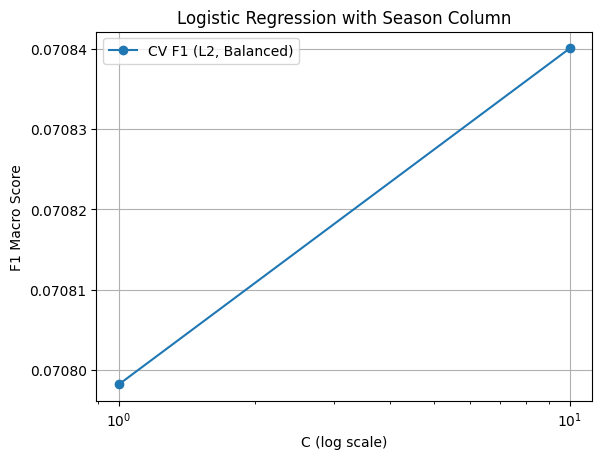


===== Season Column: Class balance = Balanced =====

L2
CV Acc: [0.0799, 0.0797]
CV F1 : [0.0708, 0.0708]
Test Acc: [0.086, 0.086]
Test F1 : [0.0712, 0.0715]


In [17]:
# parameters to test
C_values = [1, 10]
penalties = ['l2']
class_weights = ['balanced']

# store results
results_no_desc = {}

for cw in class_weights:
    cw_label = 'None' if cw is None else 'Balanced'
    results_no_desc[cw_label] = {}

    for penalty in penalties:
        label = penalty.upper()

        cv_acc_scores = []
        cv_f1_scores = []
        test_acc_scores = []
        test_f1_scores = []

        print(f"\n=== No Desc Columns: Penalty = {label}, Class Weight = {cw_label} ===")

        for C in C_values:
            print(f"Training with C = {C}")

            clf = LogisticRegression(
                max_iter=5000,
                C=C,
                solver='saga',
                penalty=penalty,
                class_weight=cw,
                random_state=42
            )

            # cross-validation
            acc_scores = cross_val_score(
                clf, X_train, y_train, cv=5, scoring='accuracy'
            )

            f1_scores = cross_val_score(
                clf, X_train, y_train, cv=5, scoring='f1_macro'
            )

            cv_acc_scores.append(acc_scores.mean())
            cv_f1_scores.append(f1_scores.mean())

            # train on full training set
            clf.fit(X_train, y_train)

            # test evaluation
            y_pred = clf.predict(X_test)

            test_acc = accuracy_score(y_test, y_pred)
            test_f1 = f1_score(y_test, y_pred, average='macro')

            test_acc_scores.append(test_acc)
            test_f1_scores.append(test_f1)

            print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
            print(f"Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}")
            print("-" * 50)

        results_no_desc[cw_label][label] = {
            'cv_acc': cv_acc_scores,
            'cv_f1': cv_f1_scores,
            'test_acc': test_acc_scores,
            'test_f1': test_f1_scores
        }

# -------- Plot --------
plt.figure()

for cw_label in results_no_desc:
    for label in results_no_desc[cw_label]:
        plt.plot(
            C_values,
            results_no_desc[cw_label][label]['cv_f1'],
            marker='o',
            label=f'CV F1 ({label}, {cw_label})'
        )

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('F1 Macro Score')
plt.title('Logistic Regression with Season Column')
plt.legend()
plt.grid(True)

plt.savefig("logreg_season.png", dpi=300, bbox_inches='tight')
plt.show()

# -------- Print Results --------
for cw_label in results_no_desc:
    print(f"\n===== Season Column: Class balance = {cw_label} =====")
    for label in results_no_desc[cw_label]:
        print(f"\n{label}")
        print("CV Acc:", [round(float(x), 4) for x in results_no_desc[cw_label][label]['cv_acc']])
        print("CV F1 :", [round(float(x), 4) for x in results_no_desc[cw_label][label]['cv_f1']])
        print("Test Acc:", [round(float(x), 4) for x in results_no_desc[cw_label][label]['test_acc']])
        print("Test F1 :", [round(float(x), 4) for x in results_no_desc[cw_label][label]['test_f1']])

#### 6. Add Sine Function for Day of Week

In [22]:
X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

X_train["Day_sin"] = np.sin(2 * np.pi * X_train["Day of Week"] / 7)
X_test["Day_sin"] = np.sin(2 * np.pi * X_test["Day of Week"] / 7)


=== No Desc Columns: Penalty = L2, Class Weight = Balanced ===
Training with C = 1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated

CV Acc: 0.0790, CV F1: 0.0705
Test Acc: 0.0819, Test F1: 0.0691
--------------------------------------------------
Training with C = 10


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated

CV Acc: 0.0780, CV F1: 0.0696
Test Acc: 0.0823, Test F1: 0.0695
--------------------------------------------------


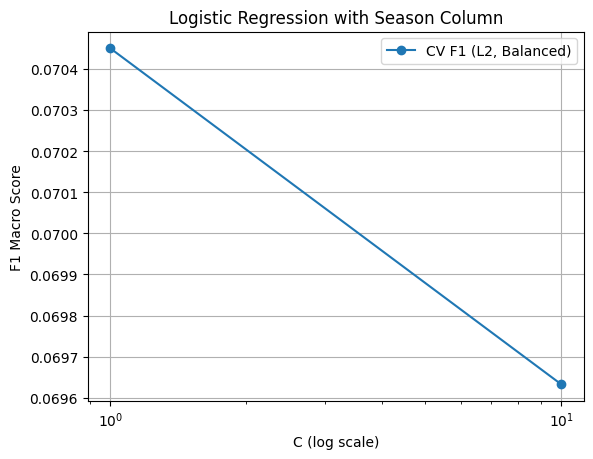


===== Season Column: Class balance = Balanced =====

L2
CV Acc: [0.079, 0.078]
CV F1 : [0.0705, 0.0696]
Test Acc: [0.0819, 0.0823]
Test F1 : [0.0691, 0.0695]


In [24]:
# parameters to test
C_values = [1, 10]
penalties = ['l2']
class_weights = ['balanced']

# store results
results_no_desc = {}

for cw in class_weights:
    cw_label = 'None' if cw is None else 'Balanced'
    results_no_desc[cw_label] = {}

    for penalty in penalties:
        label = penalty.upper()

        cv_acc_scores = []
        cv_f1_scores = []
        test_acc_scores = []
        test_f1_scores = []

        print(f"\n=== No Desc Columns: Penalty = {label}, Class Weight = {cw_label} ===")

        for C in C_values:
            print(f"Training with C = {C}")

            clf = LogisticRegression(
                max_iter=5000,
                C=C,
                solver='saga',
                penalty=penalty,
                class_weight=cw,
                random_state=42
            )

            # cross-validation
            acc_scores = cross_val_score(
                clf, X_train, y_train, cv=5, scoring='accuracy'
            )

            f1_scores = cross_val_score(
                clf, X_train, y_train, cv=5, scoring='f1_macro'
            )

            cv_acc_scores.append(acc_scores.mean())
            cv_f1_scores.append(f1_scores.mean())

            # train on full training set
            clf.fit(X_train, y_train)

            # test evaluation
            y_pred = clf.predict(X_test)

            test_acc = accuracy_score(y_test, y_pred)
            test_f1 = f1_score(y_test, y_pred, average='macro')

            test_acc_scores.append(test_acc)
            test_f1_scores.append(test_f1)

            print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
            print(f"Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}")
            print("-" * 50)

        results_no_desc[cw_label][label] = {
            'cv_acc': cv_acc_scores,
            'cv_f1': cv_f1_scores,
            'test_acc': test_acc_scores,
            'test_f1': test_f1_scores
        }

# -------- Plot --------
plt.figure()

for cw_label in results_no_desc:
    for label in results_no_desc[cw_label]:
        plt.plot(
            C_values,
            results_no_desc[cw_label][label]['cv_f1'],
            marker='o',
            label=f'CV F1 ({label}, {cw_label})'
        )

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('F1 Macro Score')
plt.title('Logistic Regression with Season Column')
plt.legend()
plt.grid(True)

plt.savefig("logreg_season.png", dpi=300, bbox_inches='tight')
plt.show()

# -------- Print Results --------
for cw_label in results_no_desc:
    print(f"\n===== Season Column: Class balance = {cw_label} =====")
    for label in results_no_desc[cw_label]:
        print(f"\n{label}")
        print("CV Acc:", [round(float(x), 4) for x in results_no_desc[cw_label][label]['cv_acc']])
        print("CV F1 :", [round(float(x), 4) for x in results_no_desc[cw_label][label]['cv_f1']])
        print("Test Acc:", [round(float(x), 4) for x in results_no_desc[cw_label][label]['test_acc']])
        print("Test F1 :", [round(float(x), 4) for x in results_no_desc[cw_label][label]['test_f1']])